Veri seti özeti:
  Gözlem sayısı: 144
  Tarih aralığı: 1949-01-01 00:00:00 - 1960-12-01 00:00:00

İlk 5 gözlem:
            Passengers
Month                 
1949-01-01         112
1949-02-01         118
1949-03-01         132
1949-04-01         129
1949-05-01         121


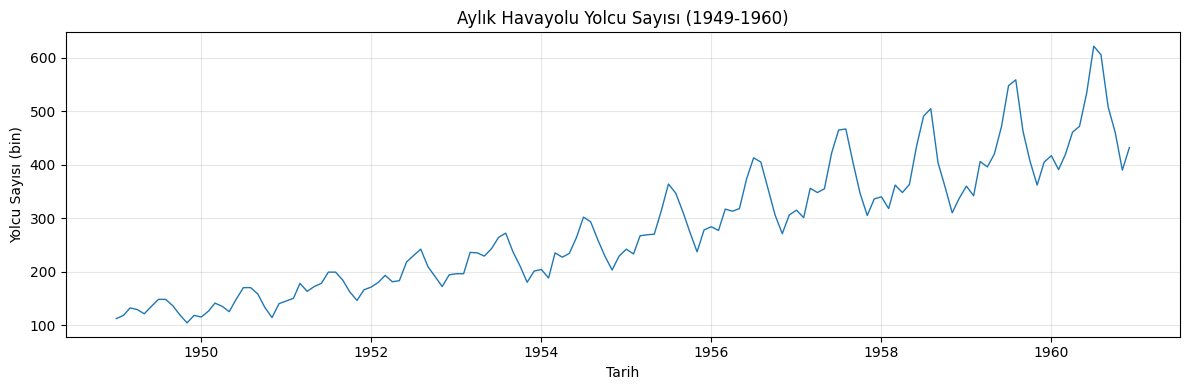


Ölçekleme sonrası:
  Min: 0.0000
  Max: 1.0000

Pencereli veri seti:
  X boyutu: (132, 12)
  y boyutu: (132,)
  X (yeniden boyutlandırılmış): (132, 12, 1)

Veri bölümü:
  Eğitim: 96 örnek
  Doğrulama: 12 örnek
  Test: 24 örnek

1D-CNN Model Mimarisi:
Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_8 (Conv1D)           (None, 12, 64)            256       
                                                                 
 batch_normalization_8 (Bat  (None, 12, 64)            256       
 chNormalization)                                                
                                                                 
 max_pooling1d_8 (MaxPoolin  (None, 6, 64)             0         
 g1D)                                                            
                                                                 
 dropout_12 (Dropout)        (None, 6, 64)             0         


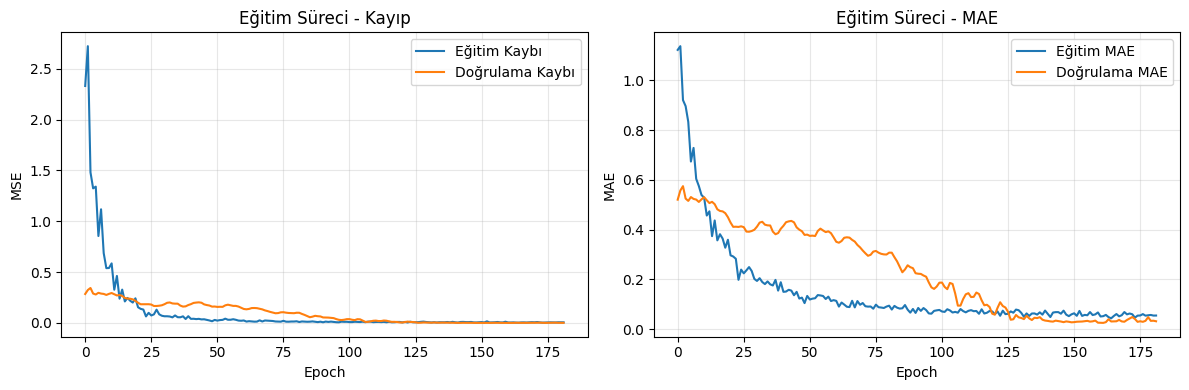


1D-CNN MODEL PERFORMANSI

Eğitim Seti Performansı:
  RMSE: 16.89
  MAE:  13.47
  MAPE: 6.30%

Doğrulama Seti Performansı:
  RMSE: 16.58
  MAE:  13.04
  MAPE: 3.47%

Test Seti Performansı:
  RMSE: 37.75
  MAE:  32.68
  MAPE: 7.28%


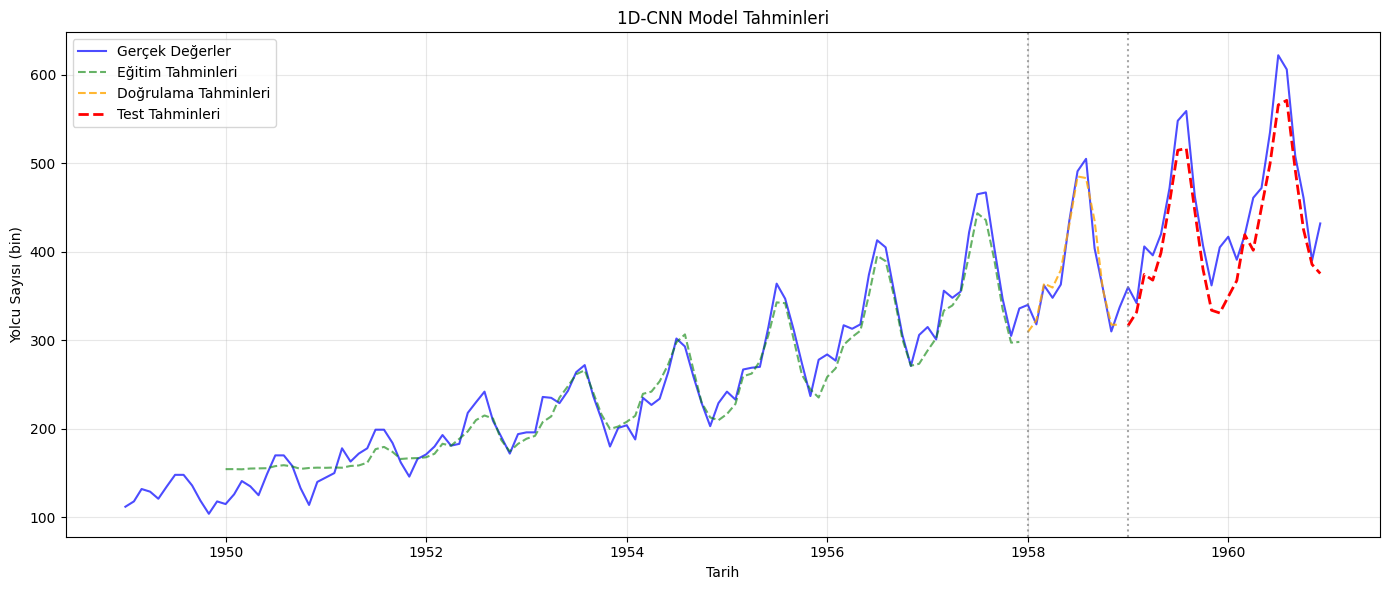

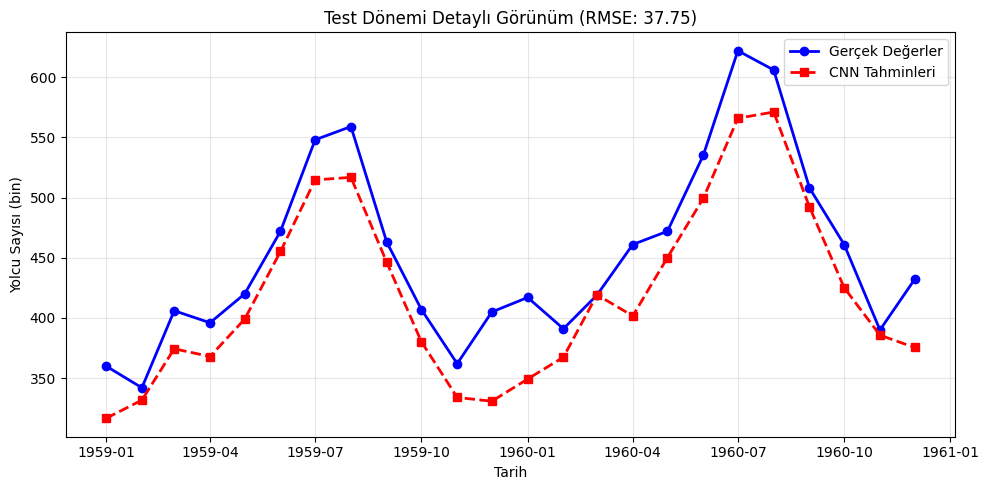

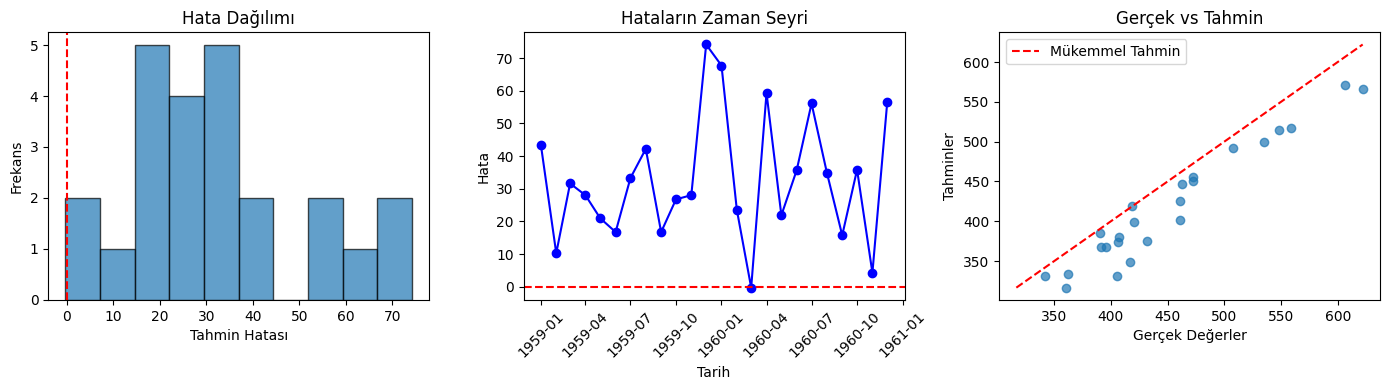


Hata İstatistikleri (Test Seti):
  Ortalama Hata: 32.66 (0'a yakın olmalı)
  Hata Std: 18.94
  Min Hata: -0.25
  Max Hata: 74.17

MODEL KARŞILAŞTIRMASI

Konfigürasyon 1: {'filters': 32, 'kernel_size': 2, 'dropout_rate': 0.1}
  Test RMSE: 321.43, MAE: 311.20

Konfigürasyon 2: {'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2}
  Test RMSE: 332.25, MAE: 323.97

Konfigürasyon 3: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3}
  Test RMSE: 174.64, MAE: 155.00

En iyi konfigürasyon: {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3}
  RMSE: 174.64

ANALİZ TAMAMLANDI

Bu çalışmada 1D-CNN ile zaman serisi tahmini gerçekleştirdik.

Model Mimarisi:
  - 2 adet Conv1D katmanı (64 ve 128 filtre)
  - BatchNormalization ile eğitim stabilizasyonu
  - MaxPooling ile boyut azaltma
  - Dropout ile aşırı öğrenme kontrolü

Sonuçlar:
  - Eğitim RMSE: 16.89
  - Doğrulama RMSE: 16.58
  - Test RMSE: 37.75
  - Test MAPE: 7.28%

CNN'in Zaman Serilerindeki Avantajları:
  - Yerel örüntüleri (tren

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Flatten, Conv1D, MaxPooling1D,
    Dropout, BatchNormalization
)
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error

# =============================================================
# 0) TEKRARLANABİLİRLİK İÇİN RASTGELELIK TOHUMLARINI AYARLAMA
# =============================================================
#
# Derin öğrenme modellerinde ağırlıkların başlangıç değerleri,
# dropout maskeleri ve veri karıştırma işlemleri rastgele yapılır.
# Aynı sonuçları elde edebilmek için tüm rastgelelik kaynaklarını
# kontrol altına almak gerekir.

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# =============================================================
# 1) VERİ SETİNİ YÜKLEME VE İNCELEME
# =============================================================
#
# AirPassengers verisi zaman serisi analizinde standart bir
# benchmark olarak kullanılır. 1949-1960 yılları arasında
# aylık uluslararası havayolu yolcu sayılarını içerir.
#
# Veri özellikleri:
#   - 144 gözlem (12 yıl × 12 ay)
#   - Güçlü yukarı trend
#   - 12 aylık mevsimsel döngü
#   - Zamanla artan varyans (heteroskedastisite)

df = pd.read_csv('AirPassengers.csv')

# Sütun adını kontrol edip düzeltelim
if '#Passengers' in df.columns:
    df.rename(columns={'#Passengers': 'Passengers'}, inplace=True)

# Tarih indeksini ayarlayalım
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

print("Veri seti özeti:")
print(f"  Gözlem sayısı: {len(df)}")
print(f"  Tarih aralığı: {df.index.min()} - {df.index.max()}")
print(f"\nİlk 5 gözlem:\n{df.head()}")

# Hedef değişkeni numpy array olarak alalım
# float32 TensorFlow için optimize edilmiş veri tipidir
data = df['Passengers'].values.astype('float32').reshape(-1, 1)

# Veriyi görselleştirelim
plt.figure(figsize=(12, 4))
plt.plot(df.index, df['Passengers'], linewidth=1)
plt.title('Aylık Havayolu Yolcu Sayısı (1949-1960)')
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================
# 2) VERİ ÖN İŞLEME
# =============================================================
#
# Sinir ağları, giriş değerlerinin belirli bir aralıkta olmasını
# tercih eder. Çok büyük veya çok küçük değerler:
#   - Gradyan patlamasına veya sönmesine yol açabilir
#   - Aktivasyon fonksiyonlarının doygun bölgelerine düşürebilir
#   - Öğrenmeyi yavaşlatabilir
#
# MinMaxScaler veriyi [0, 1] aralığına dönüştürür:
#   x_scaled = (x - x_min) / (x_max - x_min)

scaler = MinMaxScaler(feature_range=(0, 1))
data_scaled = scaler.fit_transform(data)

print(f"\nÖlçekleme sonrası:")
print(f"  Min: {data_scaled.min():.4f}")
print(f"  Max: {data_scaled.max():.4f}")


# =============================================================
# 3) PENCERELİ VERİ SETİ OLUŞTURMA
# =============================================================
#
# CNN modeli sabit boyutlu girdi bekler. Zaman serisini "sliding
# window" (kayan pencere) yöntemiyle girdi-çıktı çiftlerine
# dönüştürüyoruz.
#
# Örnek (look_back=3):
#   Giriş: [y1, y2, y3] → Çıkış: y4
#   Giriş: [y2, y3, y4] → Çıkış: y5
#   ...
#
# look_back parametresi kritik bir hiperparametredir:
#   - Çok küçük: Model yeterli bağlamı göremez
#   - Çok büyük: Model karmaşıklaşır, eğitim zorlaşır
#   - Mevsimsel veriler için genellikle mevsim periyodu kadar
#     (aylık veri için 12) veya katları seçilir

def create_dataset(dataset, look_back=1):
    """
    Zaman serisini gözetimli öğrenme formatına dönüştürür.

    Parametreler:
        dataset: Ölçeklenmiş zaman serisi (2D numpy array)
        look_back: Kaç geçmiş gözleme bakılacağı (pencere boyutu)

    Döndürür:
        X: Giriş matrisi, boyut (n_samples, look_back)
        y: Hedef vektörü, boyut (n_samples,)

    Not: Orijinal kodda 'range(len(dataset)-look_back-1)' kullanılmıştı.
    Bu -1 gereksiz bir gözlem kaybına yol açıyordu. Düzeltildi.
    """
    X, y = [], []
    for i in range(len(dataset) - look_back):
        # i'den i+look_back'e kadar olan pencere giriş
        X.append(dataset[i:(i + look_back), 0])
        # Pencerenin hemen sonraki değeri çıkış
        y.append(dataset[i + look_back, 0])
    return np.array(X), np.array(y)


look_back = 12  # 12 aylık pencere (bir tam mevsimsel döngü)

X, y = create_dataset(data_scaled, look_back)

print(f"\nPencereli veri seti:")
print(f"  X boyutu: {X.shape}")  # (132, 12)
print(f"  y boyutu: {y.shape}")  # (132,)

# ---------------------------------------------------------
# CNN Giriş Formatı
# ---------------------------------------------------------
# Keras Conv1D katmanı 3 boyutlu giriş bekler:
#   (batch_size, timesteps, features)
#
# Bizim durumumuzda:
#   - batch_size: Eğitim sırasında belirlenir
#   - timesteps: look_back = 12 (zaman adımı sayısı)
#   - features: 1 (tek değişken - yolcu sayısı)
#
# Conv1D, bu zaman adımları üzerinde 1 boyutlu konvolüsyon uygular.
# Örneğin kernel_size=3 ile her seferinde 3 ardışık zaman adımına bakar.

X = X.reshape(X.shape[0], X.shape[1], 1)
print(f"  X (yeniden boyutlandırılmış): {X.shape}")

# =============================================================
# 4) EĞİTİM / DOĞRULAMA / TEST AYIRIMI
# =============================================================
#
# Zaman serilerinde veri bölümü kronolojik sırayı korumalıdır.
# Rastgele karıştırma yapılmaz çünkü bu "geleceği görmek" anlamına
# gelir ve gerçekçi olmayan performans tahminlerine yol açar.
#
# Üç parçalı bölüm:
#   - Eğitim: Model parametrelerini öğrenir
#   - Doğrulama: Hiperparametre ayarı ve erken durdurma için
#   - Test: Final performans değerlendirmesi (eğitimde hiç kullanılmaz)

test_size = 24  # Son 2 yıl test için
val_size = 12  # Ondan önceki 1 yıl doğrulama için
train_size = len(X) - test_size - val_size

X_train = X[:train_size]
y_train = y[:train_size]

X_val = X[train_size:train_size + val_size]
y_val = y[train_size:train_size + val_size]

X_test = X[train_size + val_size:]
y_test = y[train_size + val_size:]

print(f"\nVeri bölümü:")
print(f"  Eğitim: {len(X_train)} örnek")
print(f"  Doğrulama: {len(X_val)} örnek")
print(f"  Test: {len(X_test)} örnek")


# =============================================================
# 5) 1D-CNN MODELİNİN MİMARİSİ
# =============================================================
#
# 1D Konvolüsyonel Sinir Ağı (1D-CNN), görüntü işlemede kullanılan
# 2D-CNN'in zaman serilerine uyarlanmış halidir.
#
# Temel bileşenler:
#
# 1) Conv1D Katmanı:
#    - Filtreler (kernels) veri üzerinde kayarak yerel örüntüleri öğrenir
#    - Her filtre farklı bir özelliği (trend, ani değişim, vb.) yakalar
#    - filters: Kaç farklı örüntü aranacağı
#    - kernel_size: Filtrenin kaç zaman adımına baktığı
#    - padding='same': Çıktı boyutunu girdiyle aynı tutar
#
# 2) BatchNormalization:
#    - Her katmanın çıktısını normalize eder
#    - Eğitimi stabilize eder ve hızlandırır
#    - Internal covariate shift problemini azaltır
#
# 3) MaxPooling1D:
#    - Özellik haritasını küçültür (downsampling)
#    - En belirgin özellikleri korur, gürültüyü atar
#    - Hesaplama maliyetini azaltır
#
# 4) Dropout:
#    - Rastgele nöronları kapatarak aşırı öğrenmeyi önler
#    - Modeli genellemeye zorlar
#
# 5) Flatten:
#    - Çok boyutlu çıktıyı tek boyutlu vektöre çevirir
#    - Dense katmana bağlanmak için gerekli
#
# 6) Dense:
#    - Tam bağlantılı katman, öğrenilen özellikleri birleştirir

def build_cnn_model(look_back, filters=64, kernel_size=3, dropout_rate=0.2):
    """
    1D-CNN tabanlı zaman serisi tahmin modeli oluşturur.

    Parametreler:
        look_back: Giriş pencere boyutu
        filters: Conv1D filtre sayısı
        kernel_size: Konvolüsyon çekirdek boyutu
        dropout_rate: Dropout oranı

    Mimari:
        Conv1D → BatchNorm → MaxPool → Dropout →
        Conv1D → BatchNorm → MaxPool → Dropout →
        Flatten → Dense → Dropout → Dense (çıktı)
    """
    model = Sequential([
        # İlk Konvolüsyon Bloğu
        # padding='same' çıktı boyutunu korur (önemli: derin modeller için)
        Conv1D(
            filters=filters,
            kernel_size=kernel_size,
            activation='relu',
            padding='same',
            input_shape=(look_back, 1)
        ),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # İkinci Konvolüsyon Bloğu
        # Daha fazla filtre ile daha karmaşık örüntüler yakalanır
        Conv1D(
            filters=filters * 2,
            kernel_size=kernel_size,
            activation='relu',
            padding='same'
        ),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        Dropout(dropout_rate),

        # Düzleştirme ve Tam Bağlantılı Katmanlar
        Flatten(),
        Dense(50, activation='relu'),
        Dropout(dropout_rate),
        Dense(1)  # Regresyon çıktısı (aktivasyon yok)
    ])

    # Model derleme
    # Adam optimizer: Adaptif öğrenme oranı, çoğu durumda iyi çalışır
    # MSE loss: Regresyon için standart kayıp fonksiyonu
    model.compile(
        optimizer=Adam(learning_rate=0.001),
        loss='mse',
        metrics=['mae']
    )

    return model


model = build_cnn_model(look_back, filters=64, kernel_size=3, dropout_rate=0.2)

# Model özetini görelim
print("\n1D-CNN Model Mimarisi:")
model.summary()

# ---------------------------------------------------------
# Boyut hesabı (padding='same' ile):
# ---------------------------------------------------------
# Giriş: (batch, 12, 1)
# Conv1D_1: (batch, 12, 64)    [same padding boyutu korur]
# MaxPool_1: (batch, 6, 64)    [12/2 = 6]
# Conv1D_2: (batch, 6, 128)
# MaxPool_2: (batch, 3, 128)   [6/2 = 3]
# Flatten: (batch, 384)        [3 × 128 = 384]
# Dense_1: (batch, 50)
# Dense_2: (batch, 1)


# =============================================================
# 6) MODELİN EĞİTİLMESİ
# =============================================================
#
# Eğitim parametreleri:
#
# epochs: Tüm eğitim verisinin model üzerinden kaç kez geçtiği.
#   - Erken durdurma ile otomatik olarak optimal değer bulunur
#
# batch_size: Her gradyan güncellemesinde işlenen örnek sayısı.
#   - batch_size=1: Çok gürültülü, yavaş (orijinal kodda böyleydi)
#   - batch_size=8-32: Hız ve stabilite dengesi
#   - batch_size=n (tüm veri): Stabil ama yavaş, yerel minimumlara takılabilir
#
# Early Stopping: Doğrulama kaybı iyileşmediğinde eğitimi durdurur
#   - Aşırı öğrenmeyi önler
#   - Optimal epoch sayısını otomatik bulur

early_stop = EarlyStopping(
    monitor='val_loss',  # İzlenecek metrik
    patience=20,  # Kaç epoch iyileşme beklenecek
    restore_best_weights=True,  # En iyi ağırlıkları geri yükle
    verbose=1
)

print("\n1D-CNN modeli eğitiliyor...")
history = model.fit(
    X_train, y_train,
    epochs=300,  # Maksimum epoch (erken durdurma keser)
    batch_size=16,  # Mini-batch boyutu
    validation_data=(X_val, y_val),
    callbacks=[early_stop],
    verbose=1
)

print(f"\nEğitim {len(history.history['loss'])} epoch sürdü.")

# ---------------------------------------------------------
# Eğitim sürecinin görselleştirilmesi
# ---------------------------------------------------------
# Bu grafik modelin öğrenme dinamiklerini gösterir:
#   - Eğitim ve doğrulama kayıpları birlikte düşüyorsa: İyi
#   - Eğitim düşerken doğrulama artıyorsa: Aşırı öğrenme
#   - Her ikisi de yüksek kalıyorsa: Yetersiz öğrenme

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Kayıp grafiği
axes[0].plot(history.history['loss'], label='Eğitim Kaybı')
axes[0].plot(history.history['val_loss'], label='Doğrulama Kaybı')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('MSE')
axes[0].set_title('Eğitim Süreci - Kayıp')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# MAE grafiği
axes[1].plot(history.history['mae'], label='Eğitim MAE')
axes[1].plot(history.history['val_mae'], label='Doğrulama MAE')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].set_title('Eğitim Süreci - MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# =============================================================
# 7) TAHMİN VE PERFORMANS DEĞERLENDİRMESİ
# =============================================================

# Tahminler
train_pred = model.predict(X_train, verbose=0)
val_pred = model.predict(X_val, verbose=0)
test_pred = model.predict(X_test, verbose=0)

# ---------------------------------------------------------
# Ters ölçekleme (inverse transform)
# ---------------------------------------------------------
# Tahminler [0,1] aralığında. Orijinal ölçeğe döndürmek için
# scaler.inverse_transform kullanıyoruz.
# Bu fonksiyon 2D array bekler, bu yüzden reshape gerekebilir.

train_pred_inv = scaler.inverse_transform(train_pred)
val_pred_inv = scaler.inverse_transform(val_pred)
test_pred_inv = scaler.inverse_transform(test_pred)

y_train_inv = scaler.inverse_transform(y_train.reshape(-1, 1))
y_val_inv = scaler.inverse_transform(y_val.reshape(-1, 1))
y_test_inv = scaler.inverse_transform(y_test.reshape(-1, 1))


# ---------------------------------------------------------
# Performans metrikleri
# ---------------------------------------------------------
# RMSE: Büyük hataları daha çok cezalandırır
# MAE: Tüm hatalara eşit ağırlık verir
# MAPE: Yüzde cinsinden hata, ölçekten bağımsız karşılaştırma sağlar

def calculate_metrics(y_true, y_pred, set_name=""):
    """Performans metriklerini hesaplar ve yazdırır."""
    # Dizileri düzleştir
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"\n{set_name} Performansı:")
    print(f"  RMSE: {rmse:.2f}")
    print(f"  MAE:  {mae:.2f}")
    print(f"  MAPE: {mape:.2f}%")

    return rmse, mae, mape


print("\n" + "=" * 50)
print("1D-CNN MODEL PERFORMANSI")
print("=" * 50)

train_rmse, train_mae, train_mape = calculate_metrics(
    y_train_inv, train_pred_inv, "Eğitim Seti"
)
val_rmse, val_mae, val_mape = calculate_metrics(
    y_val_inv, val_pred_inv, "Doğrulama Seti"
)
test_rmse, test_mae, test_mape = calculate_metrics(
    y_test_inv, test_pred_inv, "Test Seti"
)

# =============================================================
# 8) TAHMİNLERİN GÖRSELLEŞTİRİLMESİ
# =============================================================
#
# Grafik, modelin gerçek verileri ne kadar iyi yakaladığını
# görsel olarak değerlendirmemizi sağlar.

# Tarih indekslerini oluştur
# create_dataset ilk look_back gözlemi "harcar"
train_dates = df.index[look_back:look_back + len(y_train)]
val_dates = df.index[look_back + len(y_train):look_back + len(y_train) + len(y_val)]
test_dates = df.index[look_back + len(y_train) + len(y_val):]

plt.figure(figsize=(14, 6))

# Gerçek değerler
plt.plot(df.index, df['Passengers'], 'b-', label='Gerçek Değerler', alpha=0.7)

# Eğitim tahminleri
plt.plot(train_dates, train_pred_inv, 'g--', label='Eğitim Tahminleri', alpha=0.6)

# Doğrulama tahminleri
plt.plot(val_dates, val_pred_inv, 'orange', linestyle='--',
         label='Doğrulama Tahminleri', alpha=0.8)

# Test tahminleri
plt.plot(test_dates, test_pred_inv, 'r--', label='Test Tahminleri', linewidth=2)

# Bölüm sınırlarını işaretle
plt.axvline(x=val_dates[0], color='gray', linestyle=':', alpha=0.7)
plt.axvline(x=test_dates[0], color='gray', linestyle=':', alpha=0.7)

plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.title('1D-CNN Model Tahminleri')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# Test dönemi detaylı görünüm
# ---------------------------------------------------------
plt.figure(figsize=(10, 5))
plt.plot(test_dates, y_test_inv, 'b-o', label='Gerçek Değerler', linewidth=2)
plt.plot(test_dates, test_pred_inv, 'r--s', label='CNN Tahminleri', linewidth=2)
plt.xlabel('Tarih')
plt.ylabel('Yolcu Sayısı (bin)')
plt.title(f'Test Dönemi Detaylı Görünüm (RMSE: {test_rmse:.2f})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# =============================================================
# 9) HATA ANALİZİ
# =============================================================
#
# Hataların dağılımını ve örüntüsünü incelemek model iyileştirme
# fırsatlarını ortaya çıkarabilir.

test_errors = y_test_inv.flatten() - test_pred_inv.flatten()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Hata dağılımı (histogram)
axes[0].hist(test_errors, bins=10, edgecolor='black', alpha=0.7)
axes[0].axvline(x=0, color='r', linestyle='--')
axes[0].set_xlabel('Tahmin Hatası')
axes[0].set_ylabel('Frekans')
axes[0].set_title('Hata Dağılımı')

# Hataların zaman içindeki seyri
axes[1].plot(test_dates, test_errors, 'b-o')
axes[1].axhline(y=0, color='r', linestyle='--')
axes[1].set_xlabel('Tarih')
axes[1].set_ylabel('Hata')
axes[1].set_title('Hataların Zaman Seyri')
axes[1].tick_params(axis='x', rotation=45)

# Gerçek değer vs Tahmin (scatter plot)
axes[2].scatter(y_test_inv, test_pred_inv, alpha=0.7)
# 45 derece çizgi (mükemmel tahmin çizgisi)
min_val = min(y_test_inv.min(), test_pred_inv.min())
max_val = max(y_test_inv.max(), test_pred_inv.max())
axes[2].plot([min_val, max_val], [min_val, max_val], 'r--', label='Mükemmel Tahmin')
axes[2].set_xlabel('Gerçek Değerler')
axes[2].set_ylabel('Tahminler')
axes[2].set_title('Gerçek vs Tahmin')
axes[2].legend()

plt.tight_layout()
plt.show()

# Hata istatistikleri
print("\nHata İstatistikleri (Test Seti):")
print(f"  Ortalama Hata: {np.mean(test_errors):.2f} (0'a yakın olmalı)")
print(f"  Hata Std: {np.std(test_errors):.2f}")
print(f"  Min Hata: {np.min(test_errors):.2f}")
print(f"  Max Hata: {np.max(test_errors):.2f}")

# =============================================================
# 10) MODEL MİMARİSİ KARŞILAŞTIRMASI (OPSIYONEL)
# =============================================================
#
# Farklı hiperparametrelerle modelleri karşılaştırmak, en iyi
# konfigürasyonu bulmaya yardımcı olur.

print("\n" + "=" * 50)
print("MODEL KARŞILAŞTIRMASI")
print("=" * 50)

# Farklı konfigürasyonları test edelim
configs = [
    {'filters': 32, 'kernel_size': 2, 'dropout_rate': 0.1},
    {'filters': 64, 'kernel_size': 3, 'dropout_rate': 0.2},
    {'filters': 128, 'kernel_size': 3, 'dropout_rate': 0.3},
]

results = []

for i, config in enumerate(configs):
    print(f"\nKonfigürasyon {i + 1}: {config}")

    # Model oluştur
    test_model = build_cnn_model(look_back, **config)

    # Eğit
    test_model.fit(
        X_train, y_train,
        epochs=100,
        batch_size=16,
        validation_data=(X_val, y_val),
        callbacks=[EarlyStopping(patience=15, restore_best_weights=True, verbose=0)],
        verbose=0
    )

    # Test et
    pred = test_model.predict(X_test, verbose=0)
    pred_inv = scaler.inverse_transform(pred)

    rmse = np.sqrt(mean_squared_error(y_test_inv, pred_inv))
    mae = mean_absolute_error(y_test_inv, pred_inv)

    results.append({
        'config': str(config),
        'rmse': rmse,
        'mae': mae
    })

    print(f"  Test RMSE: {rmse:.2f}, MAE: {mae:.2f}")

# En iyi model
best_idx = np.argmin([r['rmse'] for r in results])
print(f"\nEn iyi konfigürasyon: {results[best_idx]['config']}")
print(f"  RMSE: {results[best_idx]['rmse']:.2f}")

# =============================================================
# ÖZET VE SONUÇ
# =============================================================

print("\n" + "=" * 50)
print("ANALİZ TAMAMLANDI")
print("=" * 50)
print(f"""
Bu çalışmada 1D-CNN ile zaman serisi tahmini gerçekleştirdik.

Model Mimarisi:
  - 2 adet Conv1D katmanı (64 ve 128 filtre)
  - BatchNormalization ile eğitim stabilizasyonu
  - MaxPooling ile boyut azaltma
  - Dropout ile aşırı öğrenme kontrolü

Sonuçlar:
  - Eğitim RMSE: {train_rmse:.2f}
  - Doğrulama RMSE: {val_rmse:.2f}
  - Test RMSE: {test_rmse:.2f}
  - Test MAPE: {test_mape:.2f}%

CNN'in Zaman Serilerindeki Avantajları:
  - Yerel örüntüleri (trend değişimleri, ani sıçramalar) iyi yakalar
  - RNN'lere göre daha hızlı eğitilir (paralelleştirilebilir)
  - Daha az parametre ile etkili sonuçlar verebilir

Dezavantajları:
  - Çok uzun vadeli bağımlılıkları yakalamakta zorlanabilir
  - Sıralı yapıyı doğrudan modellemez
  - Mevsimsellik için ek özellik mühendisliği gerekebilir

İyileştirme Önerileri:
  - Daha fazla Conv1D katmanı (derin model)
  - Dilated convolution ile geniş receptive field
  - CNN + LSTM hibrit model
  - Mevsimsel fark alınmış veriyle çalışma
""")